# BÀI TẬP 4 - ANN: Dự báo Thu nhập (Adult Income)
**Dataset:** UCI Adult Income (tải trực tiếp từ UCI)
**Label:** Thu nhập >50K hay <=50K/năm

In [1]:
# ==============================================================
# BƯỚC 1: NẠP THƯ VIỆN
# ==============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# ==============================================================
# BƯỚC 2: ĐỌC DỮ LIỆU ADULT INCOME (UCI)
# ==============================================================
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
col_names = ['age','workclass','fnlwgt','education','education-num',
             'marital-status','occupation','relationship','race','sex',
             'capital-gain','capital-loss','hours-per-week','native-country','income']

df = pd.read_csv(url, names=col_names, sep=', ', engine='python', na_values='?')
print('Shape:', df.shape)
print(df.head())
print('\nKiểu dữ liệu:')
print(df.dtypes)

Shape: (32561, 15)
   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0        

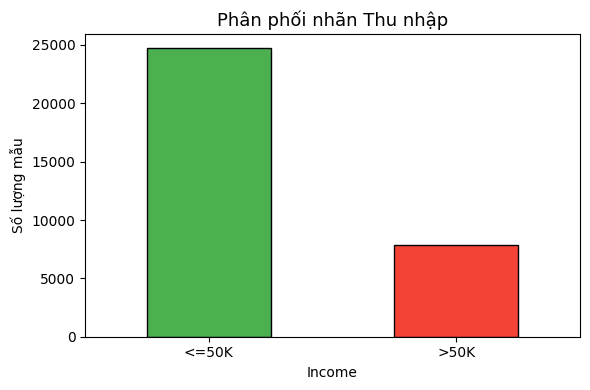

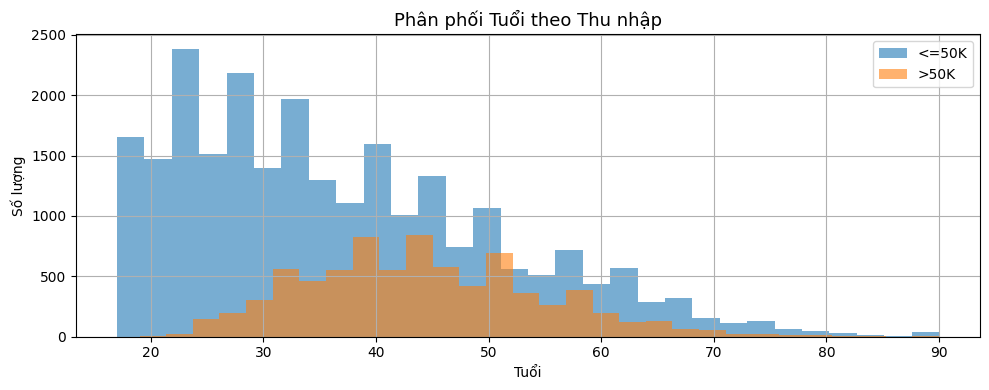

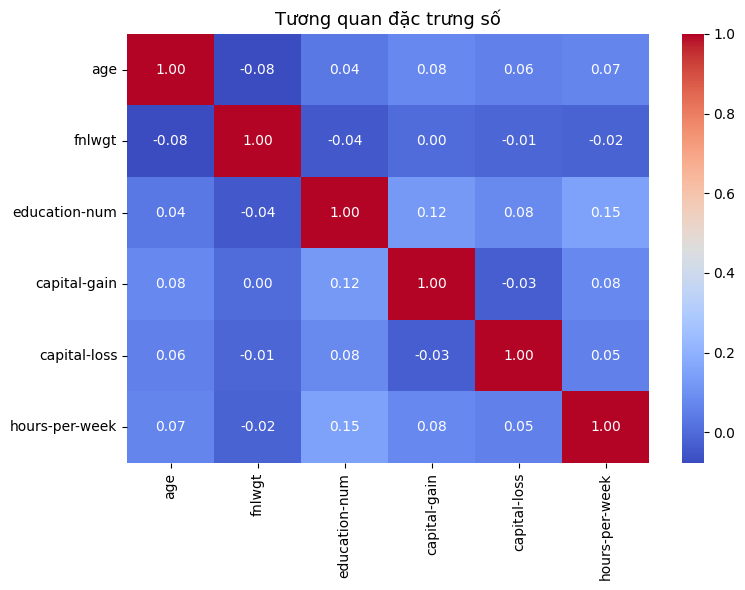

In [3]:
# ==============================================================
# BƯỚC 3: TRỰC QUAN HÓA DỮ LIỆU
# ==============================================================
# Phân phối nhãn income
plt.figure(figsize=(6, 4))
df['income'].value_counts().plot(kind='bar', color=['#4CAF50','#F44336'], edgecolor='black')
plt.title('Phân phối nhãn Thu nhập', fontsize=13)
plt.xlabel('Income')
plt.ylabel('Số lượng mẫu')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Phân phối tuổi theo nhãn
plt.figure(figsize=(10, 4))
for label in df['income'].unique():
    df[df['income']==label]['age'].hist(alpha=0.6, bins=30, label=label)
plt.title('Phân phối Tuổi theo Thu nhập', fontsize=13)
plt.xlabel('Tuổi')
plt.ylabel('Số lượng')
plt.legend()
plt.tight_layout()
plt.show()

# Heatmap tương quan đặc trưng số
plt.figure(figsize=(8, 6))
num_cols = ['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Tương quan đặc trưng số', fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
# ==============================================================
# BƯỚC 4: XỬ LÝ DỮ LIỆU
# ==============================================================
# Xử lý giá trị thiếu
df.dropna(inplace=True)
print('Shape sau khi xóa NA:', df.shape)

# Encode label
df['income'] = (df['income'] == '>50K').astype(int)

# One-hot encode các cột categorical
cat_cols = ['workclass','education','marital-status','occupation',
            'relationship','race','sex','native-country']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print('Shape sau encoding:', df_encoded.shape)

# Tách features và label
X = df_encoded.drop('income', axis=1).values.astype('float32')
y = df_encoded['income'].values

# Feature scaling
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Tách train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('Số classes:', len(np.unique(y)))

Shape sau khi xóa NA: (30162, 15)
Shape sau encoding: (30162, 97)
X_train: (24129, 96) | X_test: (6033, 96)
Số classes: 2


In [5]:
# ==============================================================
# BƯỚC 5: XÂY DỰNG MÔ HÌNH ANN
# ==============================================================
model = Sequential()

model.add(Dense(input_dim=X_train.shape[1], units=256,
                kernel_initializer='uniform', activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(units=128, kernel_initializer='uniform', activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(units=64, kernel_initializer='uniform', activation='relu'))

# Output: binary
model.add(Dense(units=1, kernel_initializer='uniform', activation='sigmoid'))

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,049 (258.00 KB)

 Trainable params: 66,049 (258.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ==============================================================
# BƯỚC 6: HUẤN LUYỆN MÔ HÌNH
# ==============================================================
model_fit = model.fit(X_train, y_train,
                      validation_split=0.1,
                      epochs=30,
                      batch_size=256,
                      verbose=1)

Epoch 1/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7494 - loss: 0.4815 - val_accuracy: 0.8160 - val_loss: 0.3832
Epoch 2/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8307 - loss: 0.3697 - val_accuracy: 0.8230 - val_loss: 0.3561
Epoch 3/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8379 - loss: 0.3512 - val_accuracy: 0.8334 - val_loss: 0.3458
Epoch 4/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8408 - loss: 0.3422 - val_accuracy: 0.8371 - val_loss: 0.3363
Epoch 5/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8439 - loss: 0.3360 - val_accuracy: 0.8392 - val_loss: 0.3356
Epoch 6/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8481 - loss: 0.3289 - val_accuracy: 0.8446 - val_loss: 0.3293
Epoch 7/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8483 - loss: 0.3241 - val_accuracy: 0.8500 - val_loss: 0.3270
Epoch 8/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8551 - loss: 0.3188 - val_accuracy: 0.8442 - val_los

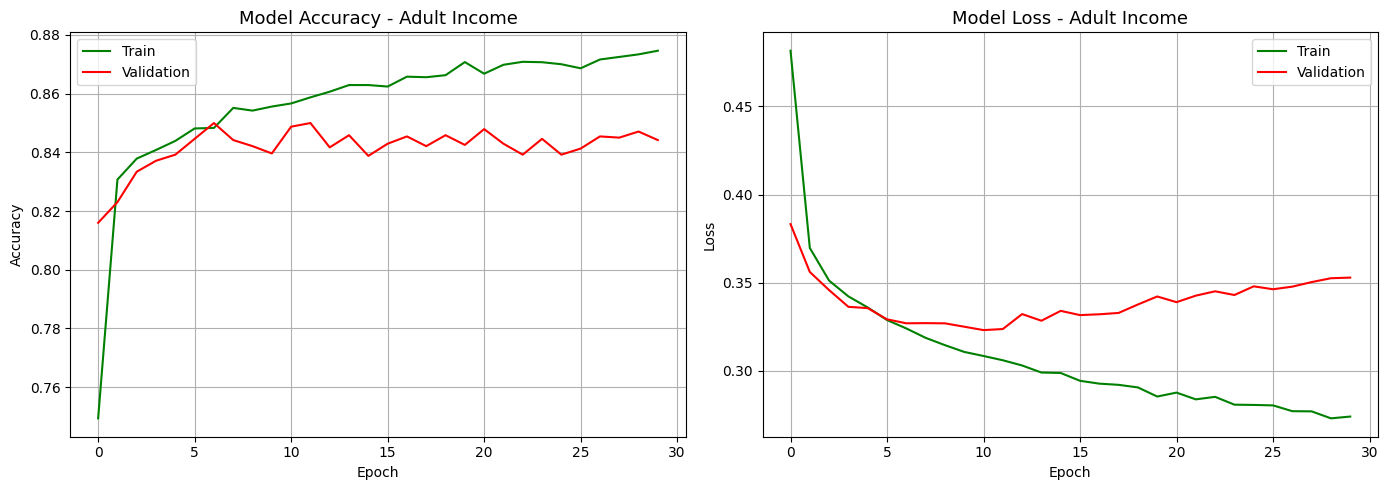

In [7]:
# ==============================================================
# BƯỚC 7: ĐÁNH GIÁ - BIỂU ĐỒ ACCURACY & LOSS
# ==============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(model_fit.history['accuracy'], label='Train', color='green')
axes[0].plot(model_fit.history['val_accuracy'], label='Validation', color='red')
axes[0].set_title('Model Accuracy - Adult Income', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(model_fit.history['loss'], label='Train', color='green')
axes[1].plot(model_fit.history['val_loss'], label='Validation', color='red')
axes[1].set_title('Model Loss - Adult Income', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

=== Classification Report ===
              precision    recall  f1-score   support

       <=50K       0.88      0.92      0.90      4531
        >50K       0.71      0.63      0.67      1502

    accuracy                           0.84      6033
   macro avg       0.80      0.77      0.78      6033
weighted avg       0.84      0.84      0.84      6033



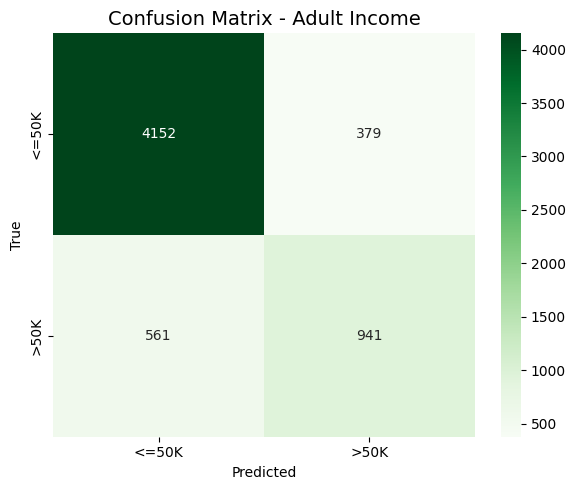


Test Accuracy: 0.8442 | Test Loss: 0.3541


In [8]:
# ==============================================================
# BƯỚC 8: CONFUSION MATRIX & CLASSIFICATION REPORT
# ==============================================================
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
class_names = ['<=50K', '>50K']

print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Adult Income', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'\nTest Accuracy: {acc:.4f} | Test Loss: {loss:.4f}')